In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [2]:
digits = load_digits()

X = digits.data
y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("类别数量:", len(set(y)))

X shape: (1797, 64)
y shape: (1797,)
类别数量: 10


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=200,
    test_size=800,
    random_state=42,
    stratify=y
)

print("训练集大小:", X_train.shape)
print("测试集大小:", X_test.shape)

训练集大小: (200, 64)
测试集大小: (800, 64)


In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([200, 64])
torch.Size([200])


In [6]:
class BigMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.net(x)

In [7]:
def train_model(model, optimizer, criterion, epochs=200):
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    
    for epoch in range(epochs):
        # 训练模式
        model.train()
        
        train_outputs = model(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        
        # 评估模式
        model.eval()
        
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            
            train_pred = torch.argmax(train_outputs, dim=1)
            test_pred = torch.argmax(test_outputs, dim=1)
            
            train_acc = (train_pred == y_train_tensor).float().mean().item()
            test_acc = (test_pred == y_test_tensor).float().mean().item()
        
        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        if (epoch + 1) % 20 == 0:
            print(
                f"Epoch [{epoch+1}/{epochs}], "
                f"Train Loss: {train_loss.item():.4f}, "
                f"Test Loss: {test_loss.item():.4f}, "
                f"Train Acc: {train_acc:.4f}, "
                f"Test Acc: {test_acc:.4f}"
            )
    
    return train_losses, test_losses, train_accs, test_accs

In [8]:
torch.manual_seed(42)

model1 = BigMLP()

criterion = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model1.parameters(), lr=0.001)

train_losses1, test_losses1, train_accs1, test_accs1 = train_model(
    model1,
    optimizer1,
    criterion,
    epochs=200
)

Epoch [20/200], Train Loss: 0.5646, Test Loss: 0.6561, Train Acc: 0.8700, Test Acc: 0.8263
Epoch [40/200], Train Loss: 0.0197, Test Loss: 0.3141, Train Acc: 1.0000, Test Acc: 0.9300
Epoch [60/200], Train Loss: 0.0014, Test Loss: 0.2998, Train Acc: 1.0000, Test Acc: 0.9362
Epoch [80/200], Train Loss: 0.0006, Test Loss: 0.3132, Train Acc: 1.0000, Test Acc: 0.9350
Epoch [100/200], Train Loss: 0.0005, Test Loss: 0.3175, Train Acc: 1.0000, Test Acc: 0.9350
Epoch [120/200], Train Loss: 0.0004, Test Loss: 0.3188, Train Acc: 1.0000, Test Acc: 0.9350
Epoch [140/200], Train Loss: 0.0003, Test Loss: 0.3198, Train Acc: 1.0000, Test Acc: 0.9350
Epoch [160/200], Train Loss: 0.0003, Test Loss: 0.3211, Train Acc: 1.0000, Test Acc: 0.9337
Epoch [180/200], Train Loss: 0.0002, Test Loss: 0.3223, Train Acc: 1.0000, Test Acc: 0.9337
Epoch [200/200], Train Loss: 0.0002, Test Loss: 0.3235, Train Acc: 1.0000, Test Acc: 0.9337


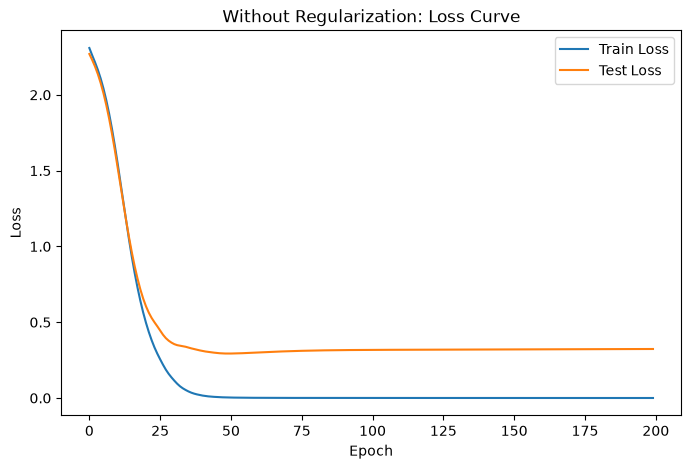

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses1, label="Train Loss")
plt.plot(test_losses1, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Without Regularization: Loss Curve")
plt.legend()
plt.show()

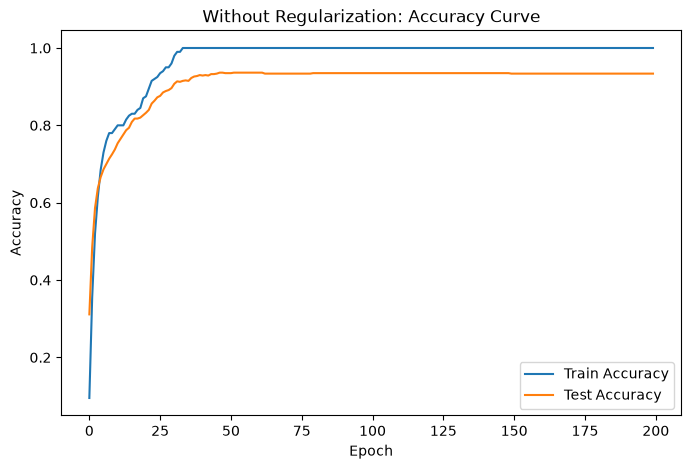

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(train_accs1, label="Train Accuracy")
plt.plot(test_accs1, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Without Regularization: Accuracy Curve")
plt.legend()
plt.show()

In [11]:
class DropoutMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.net(x)

In [12]:
torch.manual_seed(42)

model2 = DropoutMLP()

criterion = nn.CrossEntropyLoss()

optimizer2 = optim.Adam(
    model2.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

train_losses2, test_losses2, train_accs2, test_accs2 = train_model(
    model2,
    optimizer2,
    criterion,
    epochs=200
)

Epoch [20/200], Train Loss: 1.0795, Test Loss: 1.0092, Train Acc: 0.7550, Test Acc: 0.7750
Epoch [40/200], Train Loss: 0.2619, Test Loss: 0.3982, Train Acc: 0.9250, Test Acc: 0.8863
Epoch [60/200], Train Loss: 0.1049, Test Loss: 0.2709, Train Acc: 0.9700, Test Acc: 0.9312
Epoch [80/200], Train Loss: 0.0305, Test Loss: 0.2632, Train Acc: 0.9950, Test Acc: 0.9388
Epoch [100/200], Train Loss: 0.0154, Test Loss: 0.2468, Train Acc: 1.0000, Test Acc: 0.9388
Epoch [120/200], Train Loss: 0.0068, Test Loss: 0.2999, Train Acc: 1.0000, Test Acc: 0.9375
Epoch [140/200], Train Loss: 0.0404, Test Loss: 0.2697, Train Acc: 0.9950, Test Acc: 0.9312
Epoch [160/200], Train Loss: 0.0159, Test Loss: 0.2606, Train Acc: 0.9950, Test Acc: 0.9400
Epoch [180/200], Train Loss: 0.0076, Test Loss: 0.2663, Train Acc: 1.0000, Test Acc: 0.9425
Epoch [200/200], Train Loss: 0.0043, Test Loss: 0.2623, Train Acc: 1.0000, Test Acc: 0.9425


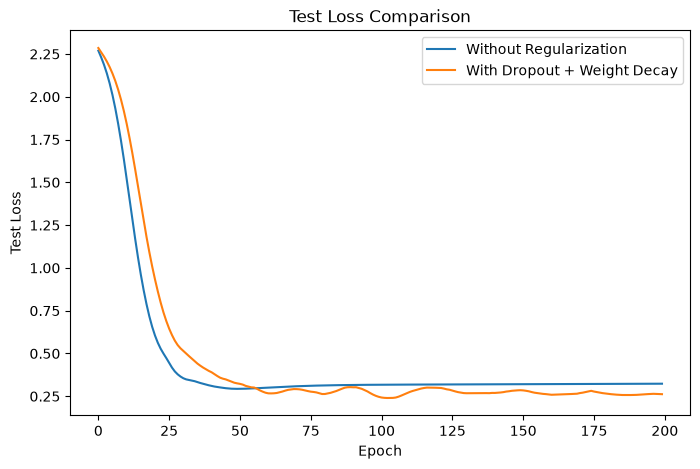

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(test_losses1, label="Without Regularization")
plt.plot(test_losses2, label="With Dropout + Weight Decay")

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss Comparison")
plt.legend()
plt.show()

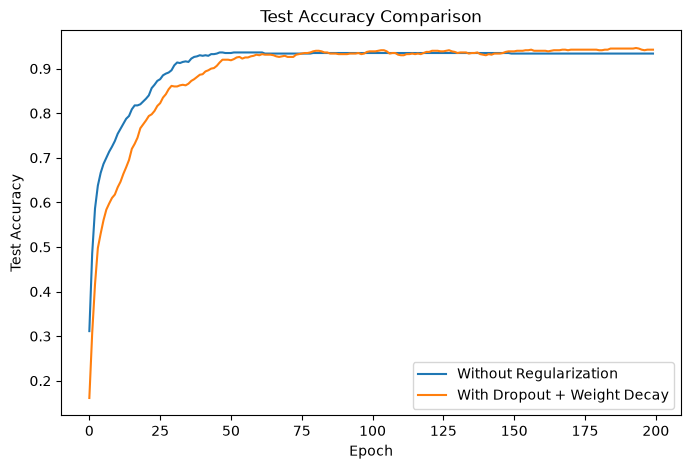

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(test_accs1, label="Without Regularization")
plt.plot(test_accs2, label="With Dropout + Weight Decay")

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.show()

In [15]:
print("普通模型最终训练准确率:", train_accs1[-1])
print("普通模型最终测试准确率:", test_accs1[-1])

print("正则化模型最终训练准确率:", train_accs2[-1])
print("正则化模型最终测试准确率:", test_accs2[-1])

普通模型最终训练准确率: 1.0
普通模型最终测试准确率: 0.9337499737739563
正则化模型最终训练准确率: 1.0
正则化模型最终测试准确率: 0.9424999952316284
